# Master Flat Creation

This notebook creates the final normalized R-band master flat from five dome-flat exposures.

An initial exploratory reduction showed that normalizing each full flat by one global median introduced a systematic mismatch between the two CCD amplifier regions. The measured amplifier median ratio was approximately **0.966**, and applying that flat increased the sky discontinuity at the amplifier boundary.

The final procedure therefore normalizes each amplifier independently before combining the flats.

Workflow:

1. Overscan-correct and trim each flat.
2. Subtract the master bias.
3. Measure the illumination level in each amplifier independently.
4. Normalize each amplifier by its own robust median.
5. Reconstruct each normalized flat.
6. Median-combine the five normalized flats.
7. Validate the amplifier balance and save the final master flat.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.stats import sigma_clipped_stats

In [2]:
PROJECT_DIR = Path("..").resolve()

FLAT_DIR = PROJECT_DIR / "Flats"
PRODUCTS_DIR = PROJECT_DIR / "products"
FIGURES_DIR = PROJECT_DIR / "Figures"

PRODUCTS_DIR.mkdir(exist_ok=True)
FIGURES_DIR.mkdir(exist_ok=True)

flat_files = sorted(FLAT_DIR.glob("*.fits*"))
print(f"Flat frames found: {len(flat_files)}")

with fits.open(PRODUCTS_DIR / "master_bias.fits") as hdul:
    master_bias = hdul[0].data.astype(float)

print("Master Bias shape:", master_bias.shape)

Flat frames found: 5
Master Bias shape: (2048, 2048)


In [3]:
def get_image_hdu(filename):
    """Return the first HDU containing a 2D image."""
    with fits.open(filename) as hdul:
        for i, hdu in enumerate(hdul):
            if hdu.data is not None and hdu.data.ndim == 2:
                return i
    raise ValueError(f"No 2D image found in {filename}")


def overscan_correct_and_trim(data):
    """Correct the two amplifiers row-by-row and return a 2048x2048 image."""

    amp1 = data[:, 10:1034].astype(float)
    overscan1 = data[:, 1044:1084].astype(float)
    amp1 -= np.median(overscan1, axis=1, keepdims=True)

    amp2 = data[:, 1134:2158].astype(float)
    overscan2 = data[:, 1084:1124].astype(float)
    amp2 -= np.median(overscan2, axis=1, keepdims=True)

    return np.hstack([amp1, amp2])


def normalize_flat_by_amplifier(corrected_flat):
    """Normalize the two amplifier regions independently."""

    amp1 = corrected_flat[:, :1024].copy()
    amp2 = corrected_flat[:, 1024:].copy()

    _, med1, _ = sigma_clipped_stats(amp1, sigma=3, maxiters=5)
    _, med2, _ = sigma_clipped_stats(amp2, sigma=3, maxiters=5)

    amp1 /= med1
    amp2 /= med2

    return np.hstack([amp1, amp2]), med1, med2

## Check flat illumination levels

In [4]:
print("=== Flat illumination levels ===\n")

for i, filename in enumerate(flat_files, start=1):
    hdu_index = get_image_hdu(filename)

    with fits.open(filename) as hdul:
        data = hdul[hdu_index].data.astype(float)

    corrected = overscan_correct_and_trim(data) - master_bias
    _, median_level, std_level = sigma_clipped_stats(
        corrected, sigma=3, maxiters=5
    )

    print(
        f"Flat {i:02d}: median={median_level:.1f} ADU, "
        f"std={std_level:.1f} ADU, max={np.nanmax(corrected):.1f} ADU"
    )

=== Flat illumination levels ===

Flat 01: median=29846.5 ADU, std=702.8 ADU, max=61475.8 ADU
Flat 02: median=29686.0 ADU, std=698.8 ADU, max=61479.8 ADU
Flat 03: median=29525.5 ADU, std=694.0 ADU, max=61475.2 ADU
Flat 04: median=29547.8 ADU, std=695.5 ADU, max=61477.5 ADU
Flat 05: median=29710.0 ADU, std=698.5 ADU, max=61475.0 ADU


## Normalize each amplifier and combine the flats

In [5]:
normalized_flats = []

print("=== Amplifier illumination levels ===\n")

for i, filename in enumerate(flat_files, start=1):
    hdu_index = get_image_hdu(filename)

    with fits.open(filename) as hdul:
        data = hdul[hdu_index].data.astype(float)

    corrected = overscan_correct_and_trim(data) - master_bias
    normalized, med1, med2 = normalize_flat_by_amplifier(corrected)

    normalized_flats.append(normalized)

    print(
        f"Flat {i:02d}: "
        f"Amp1={med1:.2f} ADU | Amp2={med2:.2f} ADU | "
        f"ratio={med1/med2:.5f}"
    )

normalized_flats = np.asarray(normalized_flats)
master_flat = np.median(normalized_flats, axis=0)

print("\nFlat stack shape:", normalized_flats.shape)

=== Amplifier illumination levels ===

Flat 01: Amp1=29440.50 ADU | Amp2=30476.00 ADU | ratio=0.96602
Flat 02: Amp1=29282.50 ADU | Amp2=30313.25 ADU | ratio=0.96600
Flat 03: Amp1=29124.50 ADU | Amp2=30147.75 ADU | ratio=0.96606
Flat 04: Amp1=29146.00 ADU | Amp2=30172.50 ADU | ratio=0.96598
Flat 05: Amp1=29306.50 ADU | Amp2=30336.75 ADU | ratio=0.96604

Flat stack shape: (5, 2048, 2048)


In [6]:
_, med1, std1 = sigma_clipped_stats(
    master_flat[:, :1024], sigma=3, maxiters=5
)
_, med2, std2 = sigma_clipped_stats(
    master_flat[:, 1024:], sigma=3, maxiters=5
)

mean_mf, median_mf, std_mf = sigma_clipped_stats(
    master_flat, sigma=3, maxiters=5
)

print("=== Final amplifier-normalized Master Flat ===")
print(f"Amplifier 1: median={med1:.6f}, std={std1:.6f}")
print(f"Amplifier 2: median={med2:.6f}, std={std2:.6f}")
print(f"Amp1/Amp2 median ratio = {med1/med2:.6f}")

print("\nWhole detector")
print(f"Mean   : {mean_mf:.6f}")
print(f"Median : {median_mf:.6f}")
print(f"Std    : {std_mf:.6f}")
print(f"Minimum: {np.nanmin(master_flat):.6f}")
print(f"Maximum: {np.nanmax(master_flat):.6f}")

=== Final amplifier-normalized Master Flat ===
Amplifier 1: median=1.000060, std=0.013941
Amplifier 2: median=1.000139, std=0.014563
Amp1/Amp2 median ratio = 0.999920

Whole detector
Mean   : 0.998731
Median : 1.000103
Std    : 0.014231
Minimum: -0.003665
Maximum: 2.068061


The final amplifier medians are expected to be very close to 1. This prevents the flat itself from introducing an artificial step at the boundary between the two readout channels.

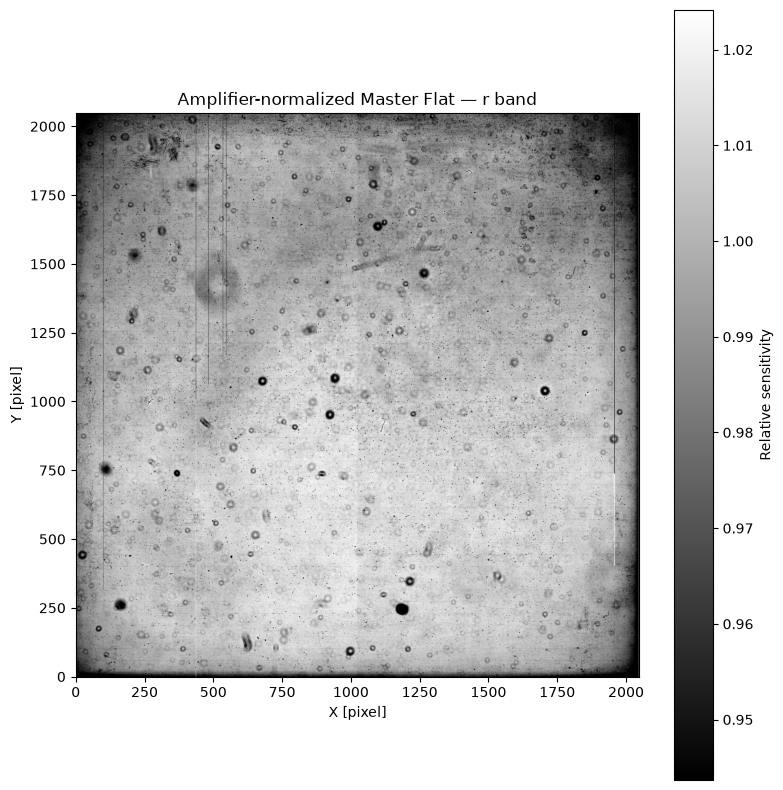

In [7]:
vmin, vmax = np.nanpercentile(master_flat, [2, 98])

plt.figure(figsize=(8, 8))
plt.imshow(
    master_flat,
    origin="lower",
    cmap="gray",
    vmin=vmin,
    vmax=vmax
)
plt.colorbar(label="Relative sensitivity")
plt.xlabel("X [pixel]")
plt.ylabel("Y [pixel]")
plt.title("Amplifier-normalized Master Flat — r band")
plt.tight_layout()

plt.savefig(FIGURES_DIR / "master_flat_r.png", dpi=150, bbox_inches="tight")
plt.show()

## Save calibration product

In [8]:
header = fits.Header()
header["IMAGETYP"] = "MASTER_FLAT"
header["FILTER"] = "r"
header["NCOMBINE"] = len(flat_files)
header["DETECTOR"] = "Tek2K_3"
header["HISTORY"] = "Two-amplifier overscan correction applied"
header["HISTORY"] = "Master bias subtracted"
header["HISTORY"] = "Each amplifier normalized independently"
header["HISTORY"] = "Five normalized flats combined using median"

master_flat_path = PRODUCTS_DIR / "master_flat_r_ampnorm.fits"

fits.writeto(
    master_flat_path,
    master_flat.astype(np.float32),
    header=header,
    overwrite=True
)

print("Saved:", master_flat_path)

Saved: C:\Users\rodri\NoirLab\products\master_flat_r_ampnorm.fits
